In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import joblib

mlflow.set_tracking_uri("sqlite:///D:/Customer Churn Prediction/Customer-Churn-Prediction/notebooks/mlflow.db")

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Option A: load from MLflow registry using a run_id from your comparison table
# model = mlflow.xgboost.load_model(f"runs:/<RUN_ID>/model")

# Option B: load from local pickle (from train.py)
model = joblib.load('../models/churn_model.pkl')

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

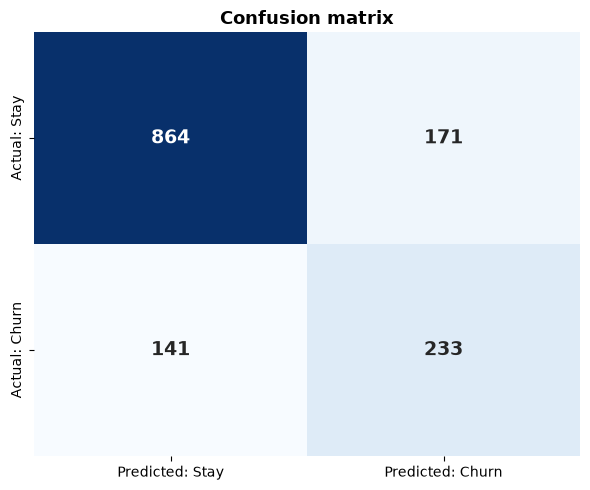


Business interpretation:
  True Negatives  (864): Correctly identified loyal customers — no action needed
  False Positives (171): Flagged as risk but stayed — cost of unnecessary retention offer
  False Negatives (141): Missed churners — LOST CUSTOMERS, the costly error
  True Positives  (233): Correctly caught churners — retention campaign can target them



In [3]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Confusion matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/05_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(f"""
Business interpretation:
  True Negatives  ({tn}): Correctly identified loyal customers — no action needed
  False Positives ({fp}): Flagged as risk but stayed — cost of unnecessary retention offer
  False Negatives ({fn}): Missed churners — LOST CUSTOMERS, the costly error
  True Positives  ({tp}): Correctly caught churners — retention campaign can target them
""")

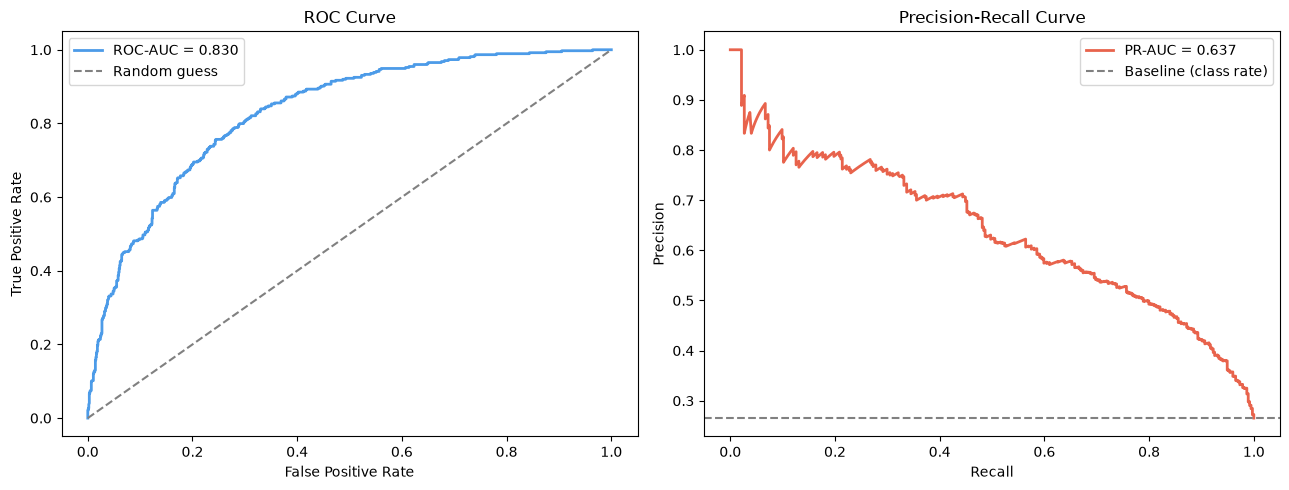

In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='#4C9BE8', linewidth=2, label=f'ROC-AUC = {roc_auc_val:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
axes[1].plot(recall, precision, color='#E8634C', linewidth=2, label=f'PR-AUC = {pr_auc:.3f}')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label='Baseline (class rate)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/06_roc_pr_curves.png', bbox_inches='tight')
plt.show()

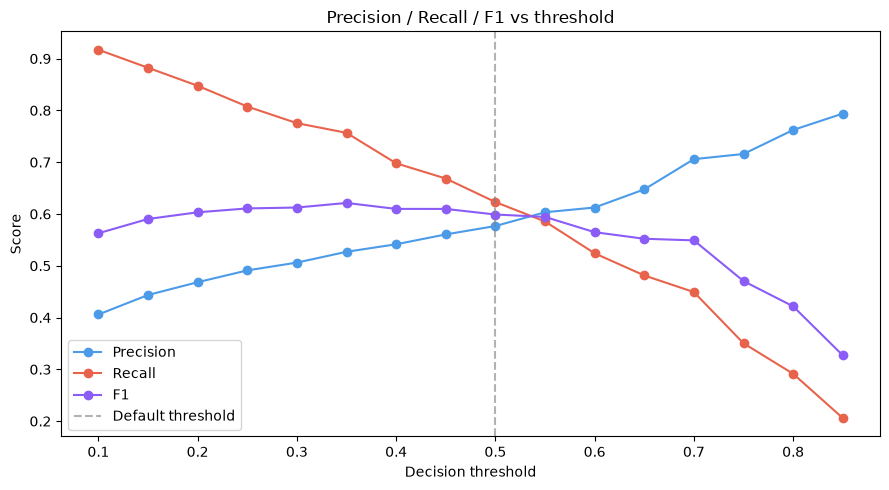

Recommended threshold for high-recall strategy:
   threshold  precision    recall        f1
5       0.35   0.527002  0.756684  0.621295


In [5]:
thresholds_to_test = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds_to_test:
    y_pred_t = (y_proba >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    results.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t),
        'recall': recall_score(y_test, y_pred_t),
        'f1': f1_score(y_test, y_pred_t)
    })

results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results_df['threshold'], results_df['precision'], marker='o', label='Precision', color='#4C9BE8')
ax.plot(results_df['threshold'], results_df['recall'], marker='o', label='Recall', color='#E8634C')
ax.plot(results_df['threshold'], results_df['f1'], marker='o', label='F1', color='#8B5CF6')
ax.axvline(0.5, linestyle='--', color='gray', alpha=0.6, label='Default threshold')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/07_threshold_tuning.png', bbox_inches='tight')
plt.show()

# Pick threshold that maximizes recall while keeping precision reasonable (business call)
best_row = results_df[results_df['recall'] >= 0.75].sort_values('precision', ascending=False).head(1)
print(f"Recommended threshold for high-recall strategy:\n{best_row}")

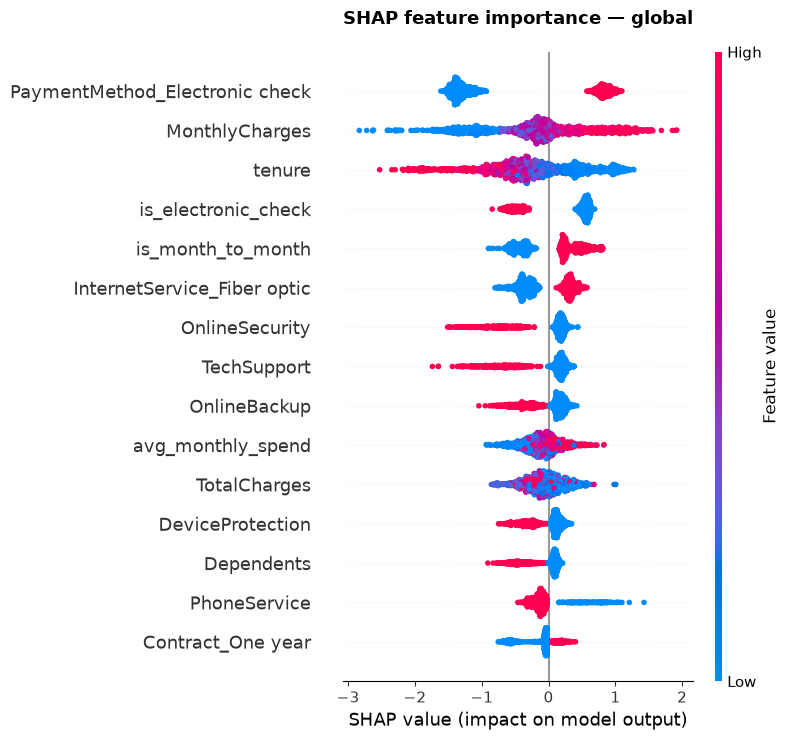

In [6]:
import shap

# For tree models, TreeExplainer is fast and exact
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# ── Global feature importance ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title('SHAP feature importance — global', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/figures/08_shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

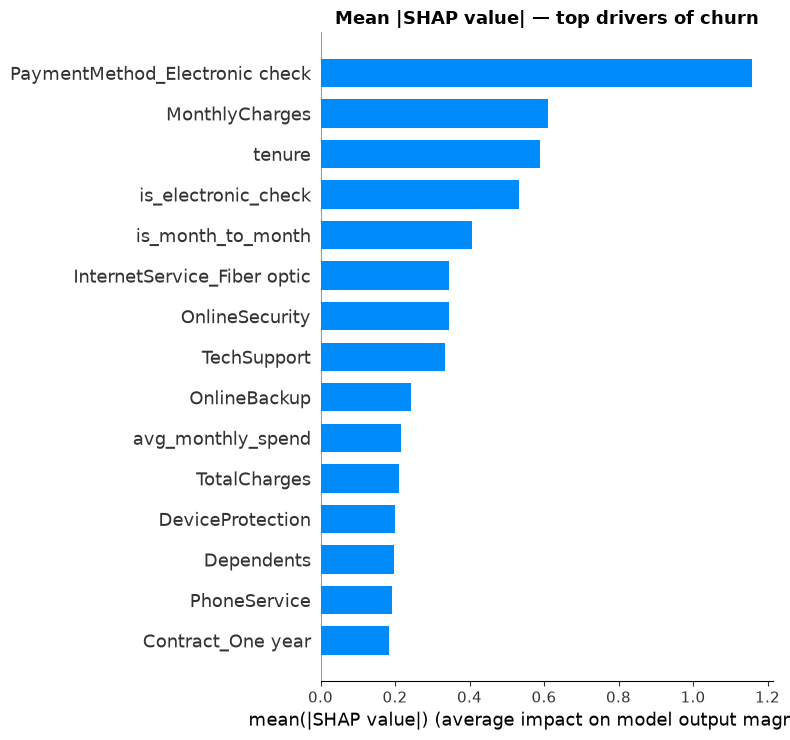

In [7]:
# ── Bar plot of mean absolute SHAP values ────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=15)
plt.title('Mean |SHAP value| — top drivers of churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/09_shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()

Customer index: 1109
Predicted churn probability: 97.99%
Actual outcome: Churned


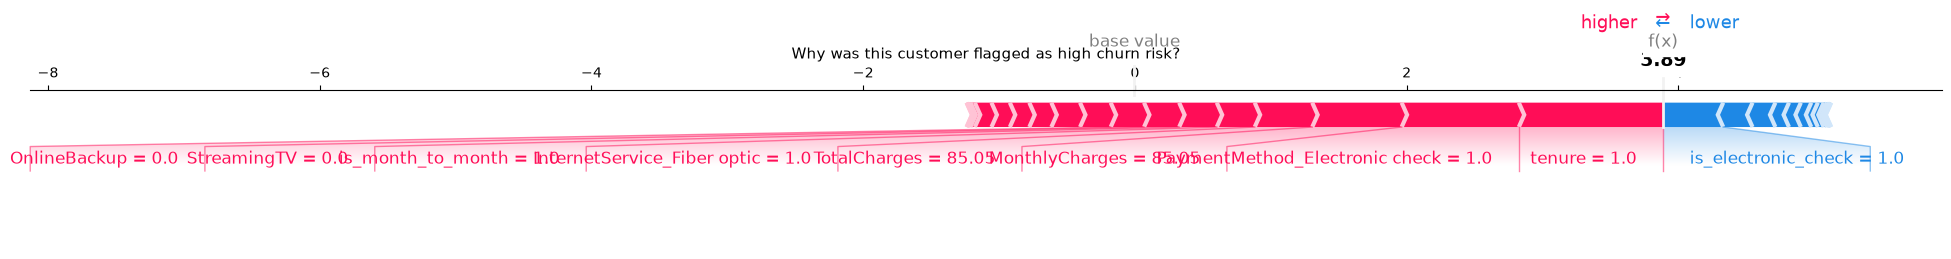

In [8]:
# Pick a customer predicted to churn with high confidence
high_risk_idx = np.argsort(y_proba)[-1]  # highest churn probability in test set

print(f"Customer index: {high_risk_idx}")
print(f"Predicted churn probability: {y_proba[high_risk_idx]:.2%}")
print(f"Actual outcome: {'Churned' if y_test.iloc[high_risk_idx] == 1 else 'Retained'}")

shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_idx],
    X_test.iloc[high_risk_idx],
    matplotlib=True,
    show=False
)
plt.title(f'Why was this customer flagged as high churn risk?', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/10_shap_individual_explanation.png', bbox_inches='tight', dpi=150)
plt.show()